# Hard Voting Ensemble (4Hz)

Transformer / CNN+Transformer / LSTM / GRU 4개 모델을 앙상블하여 테스트셋 성능을 평가합니다.

Voting: HARD | Group: 4Hz
Device: cuda:0
DATASET_PATH: /home/binghin2/Myproject/Dataset/WESAD


/tmp/ipykernel_42218/3797228606.py:441: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


[CNN+Transformer] Acc=56.48% | Macro F1=0.5578
[GRU] Acc=60.19% | Macro F1=0.5664
[LSTM] Acc=67.59% | Macro F1=0.5939
[Transformer] Acc=48.15% | Macro F1=0.4718

Ensemble Result | HARD Voting | 4Hz
Accuracy      : 53.70%
Macro F1      : 0.4993
Weighted F1   : 0.5502

Classification Report:
              precision    recall  f1-score   support

    baseline     0.6667    0.4211    0.5161        57
      stress     0.7500    0.9091    0.8219        33
   amusement     0.1250    0.2222    0.1600        18

    accuracy                         0.5370       108
   macro avg     0.5139    0.5175    0.4993       108
weighted avg     0.6019    0.5370    0.5502       108



/tmp/ipykernel_42218/3797228606.py:441: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)
/tmp/ipykernel_42218/3797228606.py:4

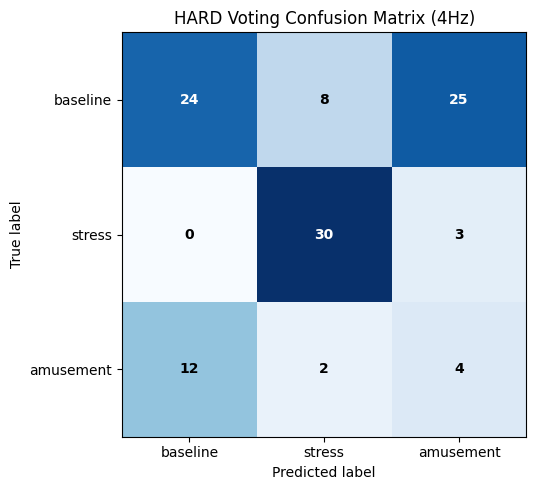

In [1]:
import os
import pickle
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

GROUP_NAME = '4Hz'
VOTING_MODE = 'hard'  # 'hard' or 'soft'

MODEL_PATHS_BY_GROUP = {
    '4Hz': [
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_0306_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/GRU/gru_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/LSTM/lstm_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/Transformer/transformer_model.pt',
    ],
    '32Hz': [
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_32hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/GRU/GRU_32hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/LSTM/LSTM_32hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/Transformer/Transformer_32hz_model.pt',
    ],
    '64Hz': [
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_64hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/GRU/GRU_64hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/LSTM/LSTM_64hz_model.pt',
        '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/Transformer/Transformer_64hz_model.pt',
    ],
}

MODEL_PATHS = MODEL_PATHS_BY_GROUP[GROUP_NAME]

DATASET_CANDIDATES = [
    '/home/binghin2/Myproject/Research/Dataset/WESAD',
    '/home/binghin2/Myproject/Dataset/WESAD',
    '../../../Dataset/WESAD',
    '../../Dataset/WESAD',
]

DATASET_PATH = None
for cand in DATASET_CANDIDATES:
    if os.path.exists(cand):
        DATASET_PATH = cand
        break
if DATASET_PATH is None:
    raise FileNotFoundError('WESAD path not found. Update DATASET_CANDIDATES.')

TEST_USERS = ['S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2}
CLASS_NAMES = ['baseline', 'stress', 'amusement']
LABEL_PURITY_THRESHOLD = 0.8
DEFAULT_WINDOW_SIZE_SEC = 60
DEFAULT_TEST_STRIDE_SEC = 60
DEFAULT_BATCH_SIZE = 64
APPLY_SUBJECT_WISE_SCALING = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Voting: {VOTING_MODE.upper()} | Group: {GROUP_NAME}')
print(f'Device: {device}')
print(f'DATASET_PATH: {DATASET_PATH}')

def _to_2d_column(signal):
    signal = np.asarray(signal)
    if signal.ndim == 1:
        return signal.reshape(-1, 1)
    return signal

def _resample_signal(signal, orig_rate, target_rate):
    signal_2d = _to_2d_column(signal)
    if orig_rate == target_rate:
        return signal_2d
    return resample_poly(signal_2d, up=target_rate, down=orig_rate, axis=0)

def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    normalized_cutoff = cutoff_hz / nyq
    b, a = butter(order, normalized_cutoff, btype='low')
    if len(eda_flat) <= (max(len(a), len(b)) * 3):
        scl = np.copy(eda_flat)
    else:
        scl = filtfilt(b, a, eda_flat)
    scr = eda_flat - scl
    return scl.reshape(-1, 1), scr.reshape(-1, 1)

def extract_bvp_features(bvp, orig_rate=64, target_rate=4):
    bvp_flat = np.asarray(bvp).flatten()
    min_distance = max(1, int(orig_rate * 0.3))
    peaks, _ = find_peaks(bvp_flat, distance=min_distance)

    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)

    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]

        hr_continuous = np.interp(times_target, peak_times, hr)
        ibi_continuous = np.interp(times_target, peak_times, ibi)

        ibi_series = pd.Series(ibi_continuous)
        hrv_continuous = (ibi_series.rolling(window=max(1, target_rate * 10), min_periods=1).std().fillna(0.0).values)
    else:
        hr_continuous = np.zeros(target_len)
        ibi_continuous = np.zeros(target_len)
        hrv_continuous = np.zeros(target_len)

    return np.concatenate([
        hr_continuous.reshape(-1, 1),
        ibi_continuous.reshape(-1, 1),
        hrv_continuous.reshape(-1, 1),
    ], axis=1)

def load_subject_components(subject_path, downsample_rate):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    acc = wrist['ACC']
    bvp = wrist['BVP']
    eda = wrist['EDA']
    temp = wrist['TEMP']
    labels = data['label']

    bvp_features = extract_bvp_features(bvp, orig_rate=64, target_rate=downsample_rate)
    scl_eda, scr_eda = decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2)

    acc_down = _resample_signal(acc, orig_rate=32, target_rate=downsample_rate)
    bvp_down = _resample_signal(bvp, orig_rate=64, target_rate=downsample_rate)
    eda_down = _resample_signal(eda, orig_rate=4, target_rate=downsample_rate)
    scl_down = _resample_signal(scl_eda, orig_rate=4, target_rate=downsample_rate)
    scr_down = _resample_signal(scr_eda, orig_rate=4, target_rate=downsample_rate)
    temp_down = _resample_signal(temp, orig_rate=4, target_rate=downsample_rate)

    label_timestamps = np.arange(len(labels)) / 700.0
    data_timestamps = np.arange(len(acc_down)) / float(downsample_rate)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)

    min_len = min(
        len(acc_down), len(bvp_down), len(eda_down), len(scl_down), len(scr_down),
        len(temp_down), len(bvp_features), len(labels_down)
    )

    return {
        'acc': acc_down[:min_len],
        'bvp': bvp_down[:min_len],
        'eda': eda_down[:min_len],
        'scl': scl_down[:min_len],
        'scr': scr_down[:min_len],
        'temp': temp_down[:min_len],
        'bvp_feat': bvp_features[:min_len],
        'labels': labels_down[:min_len],
    }

def build_feature_matrix(comp, n_features):
    feat10 = np.concatenate([comp['acc'], comp['bvp'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']], axis=1)
    feat9 = np.concatenate([comp['acc'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']], axis=1)
    feat6 = np.concatenate([comp['acc'], comp['bvp'], comp['eda'], comp['temp']], axis=1)

    if n_features == 10:
        feats = feat10
    elif n_features == 9:
        feats = feat9
    elif n_features == 6:
        feats = feat6
    elif n_features < 10:
        feats = feat10[:, :n_features]
    else:
        raise ValueError(f'Unsupported n_features={n_features}')

    if APPLY_SUBJECT_WISE_SCALING:
        scaler = StandardScaler()
        feats = scaler.fit_transform(feats)

    return feats.astype(np.float32)

def create_windows(features, labels, window_size_sec, stride_sec, downsample_rate):
    window_samples = int(window_size_sec * downsample_rate)
    stride_samples = max(1, int(stride_sec * downsample_rate))

    X, y = [], []
    i = 0
    max_start = len(features) - window_samples

    while i <= max_start:
        w_feat = features[i:i + window_samples]
        w_lab = labels[i:i + window_samples].astype(int)

        counts = np.bincount(w_lab)
        if counts.size > 0:
            mf = int(counts.argmax())
            purity = counts[mf] / float(window_samples)
            if mf in TARGET_LABELS and purity >= LABEL_PURITY_THRESHOLD:
                X.append(w_feat)
                y.append(TARGET_LABELS[mf])

        i += stride_samples

    return np.array(X), np.array(y)

class WesadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

test_loader_cache = {}

def get_test_loader(downsample_rate, n_features, window_size_sec, test_stride_sec, batch_size=64):
    key = (downsample_rate, n_features, window_size_sec, test_stride_sec, batch_size)
    if key in test_loader_cache:
        return test_loader_cache[key]

    test_X, test_y = [], []
    for user in TEST_USERS:
        subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
        if not os.path.exists(subject_path):
            print(f'[WARN] Missing file: {subject_path}')
            continue

        comp = load_subject_components(subject_path, downsample_rate=downsample_rate)
        feats = build_feature_matrix(comp, n_features=n_features)
        labs = comp['labels']
        X_u, y_u = create_windows(feats, labs, window_size_sec, test_stride_sec, downsample_rate)

        if X_u.size > 0:
            test_X.append(X_u)
            test_y.append(y_u)

    if len(test_X) == 0:
        raise ValueError('No test windows created.')

    X_test = np.concatenate(test_X, axis=0)
    y_test = np.concatenate(test_y, axis=0)

    ds = WesadDataset(X_test, y_test)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    test_loader_cache[key] = loader
    return loader

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.gru = nn.GRU(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, cnn_out_channels, cnn_kernel_size, cnn_pool_size, d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(cnn_pool_size)
        self.conv2 = nn.Conv1d(cnn_out_channels, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(cnn_pool_size)
        self.cnn_to_transformer = nn.Linear(cnn_out_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.transpose(1, 2)
        x = self.cnn_to_transformer(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

def get_state_dict_from_checkpoint(ckpt):
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        state_dict = ckpt['model_state_dict']
    elif isinstance(ckpt, dict):
        state_dict = ckpt
    else:
        raise ValueError('Unsupported checkpoint format')

    if len(state_dict) > 0 and list(state_dict.keys())[0].startswith('module.'):
        state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    return state_dict

def infer_output_dim(state_dict, default=3):
    for key in ['fc.weight', 'classifier.weight', 'output_layer.weight', 'head.weight']:
        if key in state_dict and len(state_dict[key].shape) == 2:
            return int(state_dict[key].shape[0])
    return default

def build_model_from_checkpoint(ckpt, state_dict, model_path):
    model_name = str(ckpt.get('model_name', '')).lower() if isinstance(ckpt, dict) else ''
    filename = os.path.basename(model_path).lower()

    output_dim = int(ckpt.get('output_dim', infer_output_dim(state_dict, default=3))) if isinstance(ckpt, dict) else 3
    input_dim = int(ckpt.get('n_features', 10)) if isinstance(ckpt, dict) else 10

    if 'cnn_transformer' in model_name or 'cnn_transformer' in filename:
        model = CNNTransformerModel(
            input_dim=input_dim,
            cnn_out_channels=int(ckpt.get('cnn_out_channels', 32)),
            cnn_kernel_size=int(ckpt.get('cnn_kernel_size', 3)),
            cnn_pool_size=int(ckpt.get('cnn_pool_size', 2)),
            d_model=int(ckpt.get('d_model', 32)),
            nhead=int(ckpt.get('nhead', 4)),
            dim_feedforward=int(ckpt.get('dim_feedforward', 128)),
            nlayers=int(ckpt.get('nlayers', 2)),
            output_dim=output_dim,
            dropout=float(ckpt.get('dropout', 0.5)),
        )
        return model, 'CNN+Transformer'

    if 'gru' in model_name or 'gru' in filename:
        model = GRUModel(
            input_dim=input_dim,
            hidden_dim=int(ckpt.get('hidden_dim', 128)),
            layer_dim=int(ckpt.get('layer_dim', 2)),
            output_dim=output_dim,
            dropout=float(ckpt.get('dropout', 0.5)),
        )
        return model, 'GRU'

    if 'lstm' in model_name or 'lstm' in filename:
        model = LSTMModel(
            input_dim=input_dim,
            hidden_dim=int(ckpt.get('hidden_dim', 128)),
            layer_dim=int(ckpt.get('layer_dim', 2)),
            output_dim=output_dim,
            dropout=float(ckpt.get('dropout', 0.5)),
        )
        return model, 'LSTM'

    model = TransformerModel(
        input_dim=input_dim,
        d_model=int(ckpt.get('d_model', 32)),
        nhead=int(ckpt.get('nhead', 4)),
        dim_feedforward=int(ckpt.get('dim_feedforward', 128)),
        nlayers=int(ckpt.get('nlayers', 2)),
        output_dim=output_dim,
        dropout=float(ckpt.get('dropout', 0.5)),
    )
    return model, 'Transformer'

@torch.no_grad()
def infer_model_probs(model, loader, dev):
    model.eval()
    probs_list = []
    labels_list = []
    for sequences, labels in loader:
        sequences = sequences.to(dev)
        logits = model(sequences)
        probs = torch.softmax(logits, dim=1)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(labels.numpy())

    probs_all = np.concatenate(probs_list, axis=0)
    labels_all = np.concatenate(labels_list, axis=0)
    preds_all = np.argmax(probs_all, axis=1)
    return probs_all, preds_all, labels_all

fallback_rate = int(GROUP_NAME.replace('Hz', ''))
all_model_probs = []
all_model_preds = []
ensemble_labels = None
model_names = []

for model_path in MODEL_PATHS:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Missing model: {model_path}')

    ckpt = torch.load(model_path, map_location=device)
    state_dict = get_state_dict_from_checkpoint(ckpt)

    n_features = int(ckpt.get('n_features', 10)) if isinstance(ckpt, dict) else 10
    downsample_rate = int(ckpt.get('downsample_rate', ckpt.get('DOWNSAMPLE_RATE', fallback_rate))) if isinstance(ckpt, dict) else fallback_rate
    window_size_sec = int(ckpt.get('window_size_sec', ckpt.get('WINDOW_SIZE_SEC', DEFAULT_WINDOW_SIZE_SEC))) if isinstance(ckpt, dict) else DEFAULT_WINDOW_SIZE_SEC
    test_stride_sec = int(ckpt.get('test_stride_sec', ckpt.get('TEST_STRIDE_SEC', DEFAULT_TEST_STRIDE_SEC))) if isinstance(ckpt, dict) else DEFAULT_TEST_STRIDE_SEC

    loader = get_test_loader(downsample_rate, n_features, window_size_sec, test_stride_sec, DEFAULT_BATCH_SIZE)

    model, model_name = build_model_from_checkpoint(ckpt, state_dict, model_path)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)

    probs, preds, labels = infer_model_probs(model, loader, device)

    if ensemble_labels is None:
        ensemble_labels = labels
    elif not np.array_equal(ensemble_labels, labels):
        raise RuntimeError('Label order mismatch across models.')

    all_model_probs.append(probs)
    all_model_preds.append(preds)
    model_names.append(model_name)

    indiv_acc = 100.0 * (preds == labels).mean()
    indiv_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'[{model_name}] Acc={indiv_acc:.2f}% | Macro F1={indiv_f1:.4f}')

prob_tensor = np.stack(all_model_probs, axis=0)
pred_tensor = np.stack(all_model_preds, axis=0)

if VOTING_MODE.lower() == 'soft':
    mean_probs = prob_tensor.mean(axis=0)
    ensemble_preds = np.argmax(mean_probs, axis=1)
else:
    n_models, n_samples = pred_tensor.shape
    ensemble_preds = np.zeros(n_samples, dtype=int)
    mean_probs = prob_tensor.mean(axis=0)

    for i in range(n_samples):
        votes = pred_tensor[:, i]
        counts = np.bincount(votes, minlength=len(CLASS_NAMES))
        winners = np.flatnonzero(counts == counts.max())
        if len(winners) == 1:
            ensemble_preds[i] = winners[0]
        else:
            tie_probs = mean_probs[i, winners]
            ensemble_preds[i] = winners[int(np.argmax(tie_probs))]

ensemble_acc = 100.0 * (ensemble_preds == ensemble_labels).mean()
ensemble_macro_f1 = f1_score(ensemble_labels, ensemble_preds, average='macro', zero_division=0)
ensemble_weighted_f1 = f1_score(ensemble_labels, ensemble_preds, average='weighted', zero_division=0)

print('\n' + '=' * 80)
print(f'Ensemble Result | {VOTING_MODE.upper()} Voting | {GROUP_NAME}')
print('=' * 80)
print(f'Accuracy      : {ensemble_acc:.2f}%')
print(f'Macro F1      : {ensemble_macro_f1:.4f}')
print(f'Weighted F1   : {ensemble_weighted_f1:.4f}')
print('\nClassification Report:')
print(classification_report(ensemble_labels, ensemble_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(ensemble_labels, ensemble_preds, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title(f'{VOTING_MODE.upper()} Voting Confusion Matrix ({GROUP_NAME})')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='white' if cm[i, j] > thresh else 'black', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Accuracy / F1-score plot (개별 4모델 + Ensemble)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

required = ['model_names', 'all_model_preds', 'ensemble_preds', 'ensemble_labels']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'먼저 2번 셀을 실행하세요. Missing: {missing}')

rows = []
for name, preds in zip(model_names, all_model_preds):
    acc = 100.0 * (preds == ensemble_labels).mean()
    mf1 = f1_score(ensemble_labels, preds, average='macro', zero_division=0)
    rows.append({'Model': name, 'Accuracy(%)': acc, 'Macro F1': mf1})

rows.append({
    'Model': f'Ensemble ({VOTING_MODE.upper()})',
    'Accuracy(%)': 100.0 * (ensemble_preds == ensemble_labels).mean(),
    'Macro F1': f1_score(ensemble_labels, ensemble_preds, average='macro', zero_division=0),
})

metrics_df = pd.DataFrame(rows)
display(metrics_df)

x = np.arange(len(metrics_df))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars_acc = axes[0].bar(x, metrics_df['Accuracy(%)'].values, color=['#6baed6'] * (len(metrics_df)-1) + ['#f28e2b'], edgecolor='black')
axes[0].set_title('Accuracy (%)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_df['Model'].tolist(), rotation=20, ha='right')
axes[0].set_ylim(0, 105)
axes[0].grid(axis='y', alpha=0.3)
for b in bars_acc:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h + 1.0, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

bars_f1 = axes[1].bar(x, metrics_df['Macro F1'].values, color=['#74c476'] * (len(metrics_df)-1) + ['#e15759'], edgecolor='black')
axes[1].set_title('Macro F1-score', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_df['Model'].tolist(), rotation=20, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)
for b in bars_f1:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'{GROUP_NAME} - Individual vs Ensemble ({VOTING_MODE.upper()} Voting)', fontweight='bold')
plt.tight_layout()
plt.show()